In [28]:
import pandas as pd
import numpy as np

from prophet import Prophet

from sklearn.metrics import mean_squared_error

import plotly.graph_objs as go
import plotly.offline as py

In [29]:
df_Train = pd.read_csv("DailyDelhiClimateTrain.csv")
df_Test = pd.read_csv("DailyDelhiClimateTest.csv")

In [30]:
len(df_Train)

1462

In [31]:
len(df_Test)

114

In [32]:
df_Train.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [33]:
df_Test.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


# Uni-Variate Forecasting

In [34]:
df_Train = df_Train.rename(columns = {'meantemp':'y', 'date':'ds'})
df_Train['y_orig'] = df_Train['y']
df_Train['y'] = np.log(df_Train['y'])

In [35]:
df_Train.head()

,ds,y,humidity,wind_speed,meanpressure,y_orig
0,2013-01-01,2.302585,84.500000,0.000000,1015.666667,10.000000
1,2013-01-02,2.001480,92.000000,2.980000,1017.800000,7.400000
2,2013-01-03,1.969441,87.000000,4.633333,1018.666667,7.166667
3,2013-01-04,2.159484,71.333333,1.233333,1017.166667,8.666667
4,2013-01-05,1.791759,86.833333,3.700000,1016.500000,6.000000


In [36]:
model = Prophet()
model.fit(df_Train)

16:54:22 - cmdstanpy - INFO - Chain [1] start processing
16:54:22 - cmdstanpy - INFO - Chain [1] done processing


In [37]:
future_Data = model.make_future_dataframe(periods = 113, freq = 'D')
forecast_Future = model.predict(future_Data)

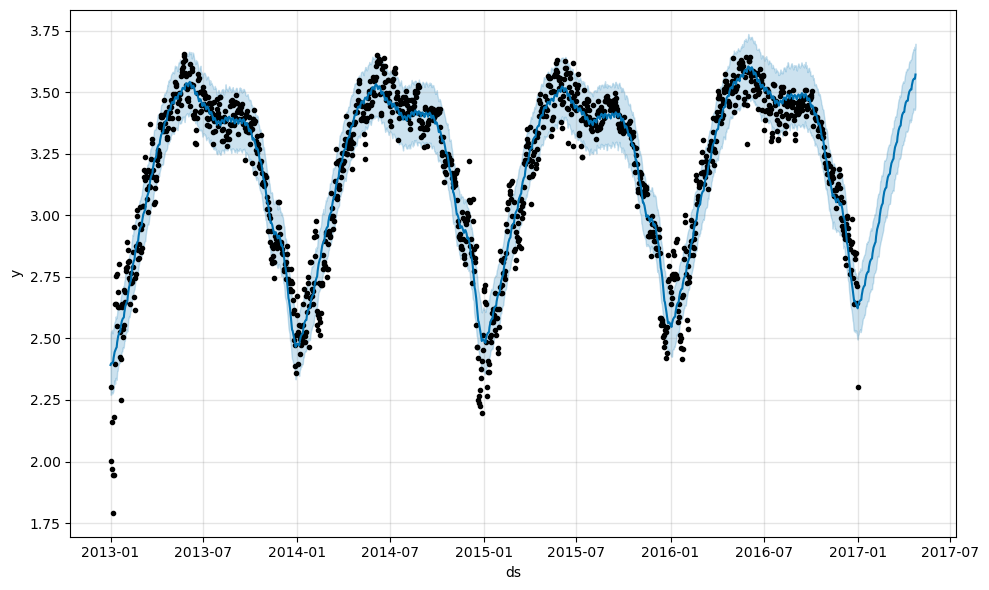

In [38]:
model.plot(forecast_Future);

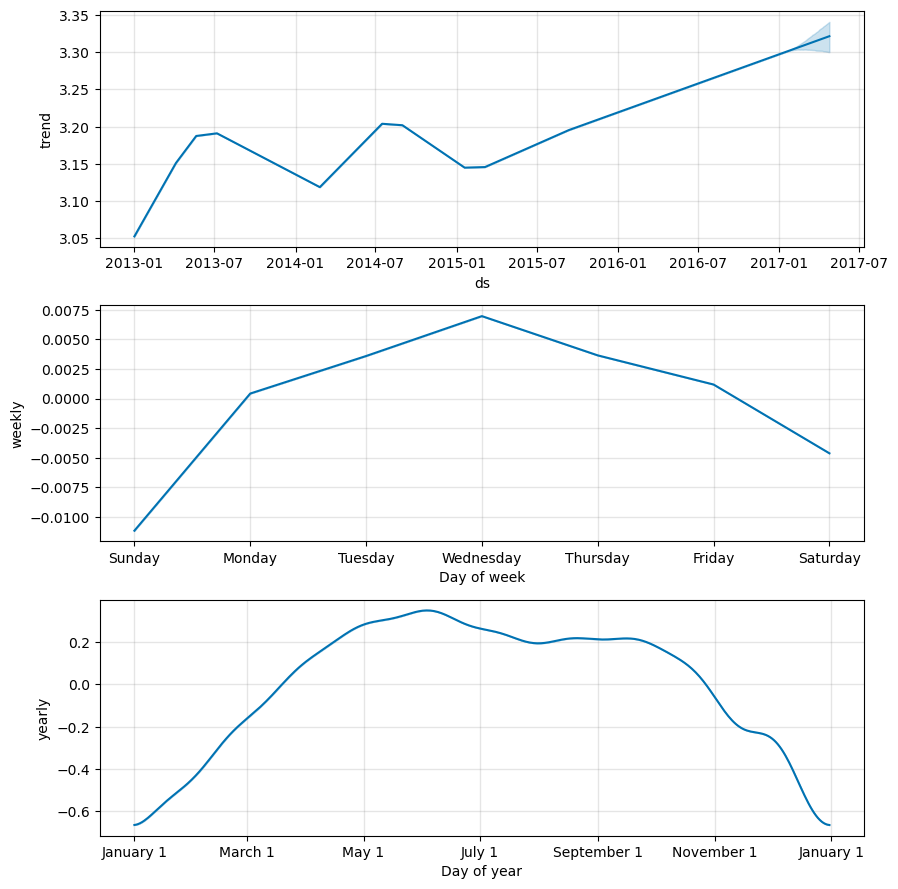

In [39]:
model.plot_components(forecast_Future);

In [40]:
forecast_data_orig = forecast_Future.copy()
forecast_data_orig["yhat"] = np.exp(forecast_data_orig["yhat"])
forecast_data_orig["yhat_lower"] = np.exp(forecast_data_orig["yhat_lower"])
forecast_data_orig["yhat_upper"] = np.exp(forecast_data_orig["yhat_upper"])

In [41]:
forecast_data_orig.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,3.052434,9.705227,12.393380,3.052434,3.052434,-0.660322,-0.660322,-0.660322,0.003585,0.003585,0.003585,-0.663908,-0.663908,-0.663908,0.0,0.0,0.0,10.936562
1,2013-01-02,3.053485,9.683092,12.560056,3.053485,3.053485,-0.655339,-0.655339,-0.655339,0.006954,0.006954,0.006954,-0.662293,-0.662293,-0.662293,0.0,0.0,0.0,11.002758
2,2013-01-03,3.054536,9.807821,12.530940,3.054536,3.054536,-0.655791,-0.655791,-0.655791,0.003641,0.003641,0.003641,-0.659432,-0.659432,-0.659432,0.0,0.0,0.0,11.009348
3,2013-01-04,3.055587,9.746400,12.616262,3.055587,3.055587,-0.654265,-0.654265,-0.654265,0.001182,0.001182,0.001182,-0.655447,-0.655447,-0.655447,0.0,0.0,0.0,11.037761
4,2013-01-05,3.056638,9.743367,12.433729,3.056638,3.056638,-0.655086,-0.655086,-0.655086,-0.004623,-0.004623,-0.004623,-0.650463,-0.650463,-0.650463,0.0,0.0,0.0,11.040299


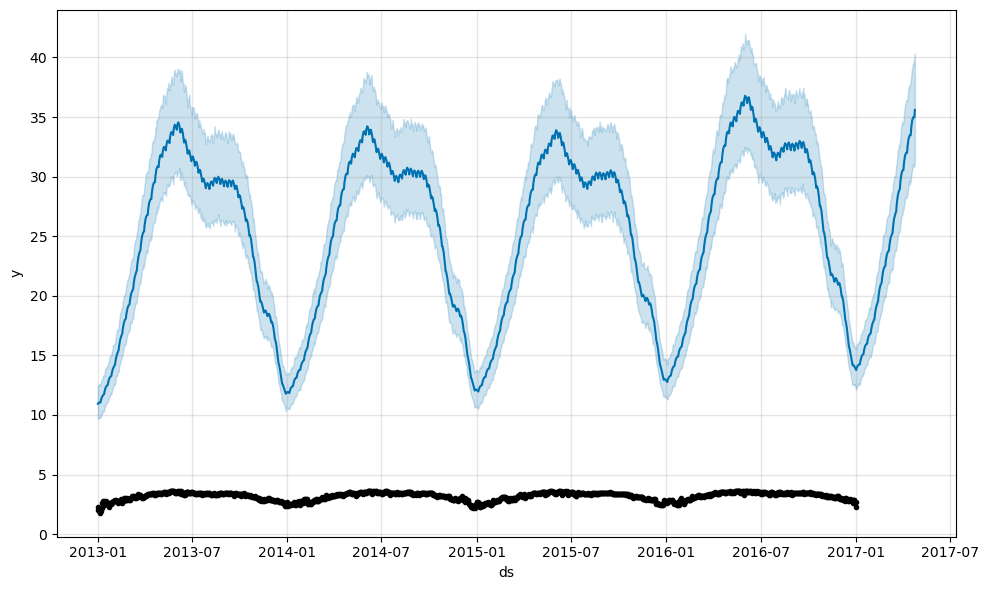

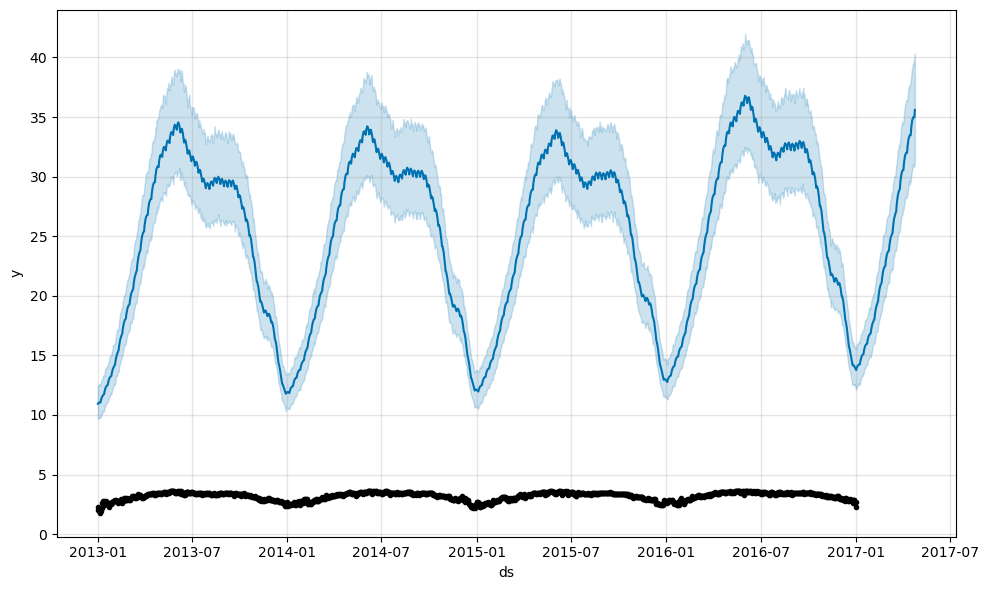

In [42]:
model.plot(forecast_data_orig)

In [43]:
df_Train["y_log"] = df_Train["y"]
df_Train["y"] = df_Train["y_orig"]

In [44]:
final_df = pd.DataFrame(forecast_data_orig)

In [45]:
actual_chart = go.Scatter(y=df_Train["y"], name= 'Actual')
predict_chart = go.Scatter(y=final_df["yhat"], name= 'Predicted')
predict_chart_upper = go.Scatter(y=final_df["yhat_upper"], name= 'Predicted Upper')
predict_chart_lower = go.Scatter(y=final_df["yhat_lower"], name= 'Predicted Lower')
py.plot([actual_chart, predict_chart, predict_chart_upper, predict_chart_lower], image_width=400, image_height=400)

'temp-plot.html'

# Multi Variat Forecasting

In [46]:
df_Train_Multi = pd.read_csv("DailyDelhiClimateTrain.csv")
df_Test_Multi = pd.read_csv("DailyDelhiClimateTest.csv")
df_Train_Multi.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [47]:
df_Test_Multi = df_Test_Multi.rename(columns = {'meantemp':'y', 'date':'ds'})
df_Test_Multi['y_orig'] = df_Test_Multi['y']

In [64]:
df_Train_Multi = df_Train_Multi.rename(columns = {'meantemp':'y', 'date':'ds'})
df_Train_Multi['y_orig'] = df_Train_Multi['y']
df_Train_Multi['y'] = np.log(df_Train_Multi['y'])

In [65]:
model_new = Prophet()
model_new.add_regressor("humidity")
model_new.add_regressor("wind_speed")
model_new.add_regressor("meanpressure")
model_new.fit(df_Train_Multi)

17:07:12 - cmdstanpy - INFO - Chain [1] start processing
17:07:12 - cmdstanpy - INFO - Chain [1] done processing


In [66]:
future_Data_New = pd.concat([df_Train_Multi, df_Test_Multi], ignore_index=True)
future_Data_New = future_Data_New.rename(columns={'date': 'ds'})
forecast_Future_New = model_new.predict(future_Data_New)

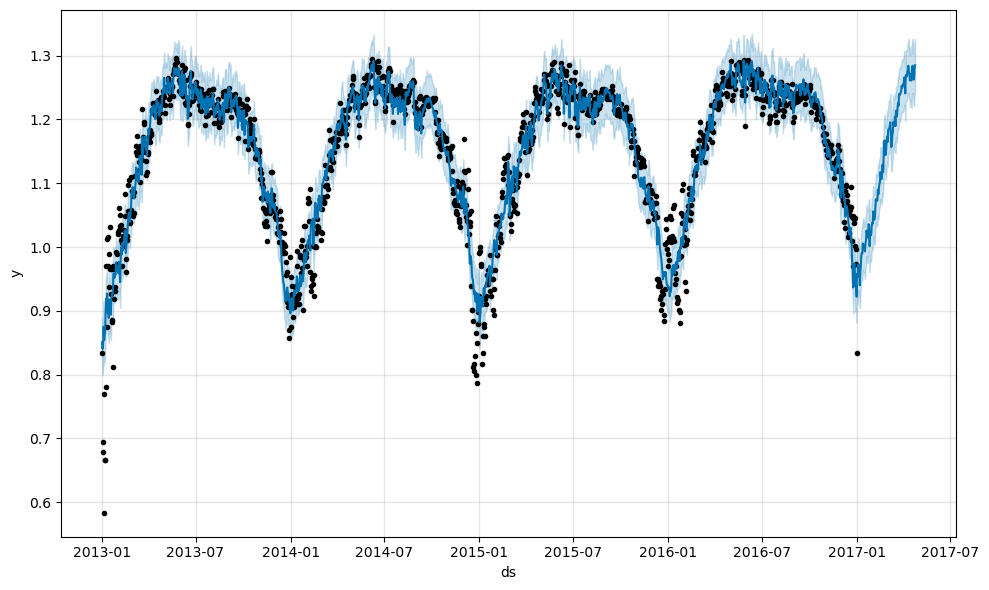

In [67]:
model_new.plot(forecast_Future_New);

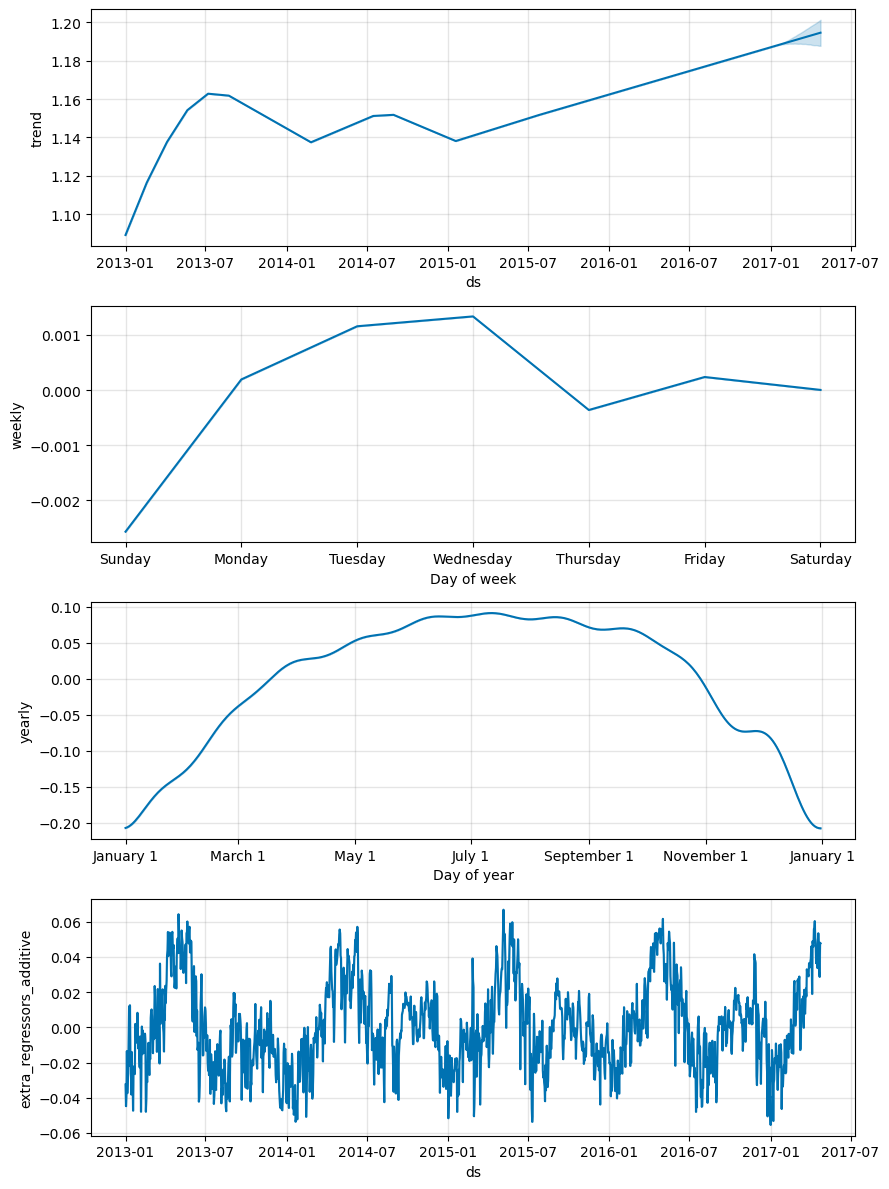

In [68]:
model_new.plot_components(forecast_Future_New);

In [74]:
forecast_data_orig = forecast_Future.copy()
forecast_data_orig["yhat"] = np.exp(forecast_data_orig["yhat"])
forecast_data_orig["yhat_lower"] = np.exp(forecast_data_orig["yhat_lower"])
forecast_data_orig["yhat_upper"] = np.exp(forecast_data_orig["yhat_upper"])

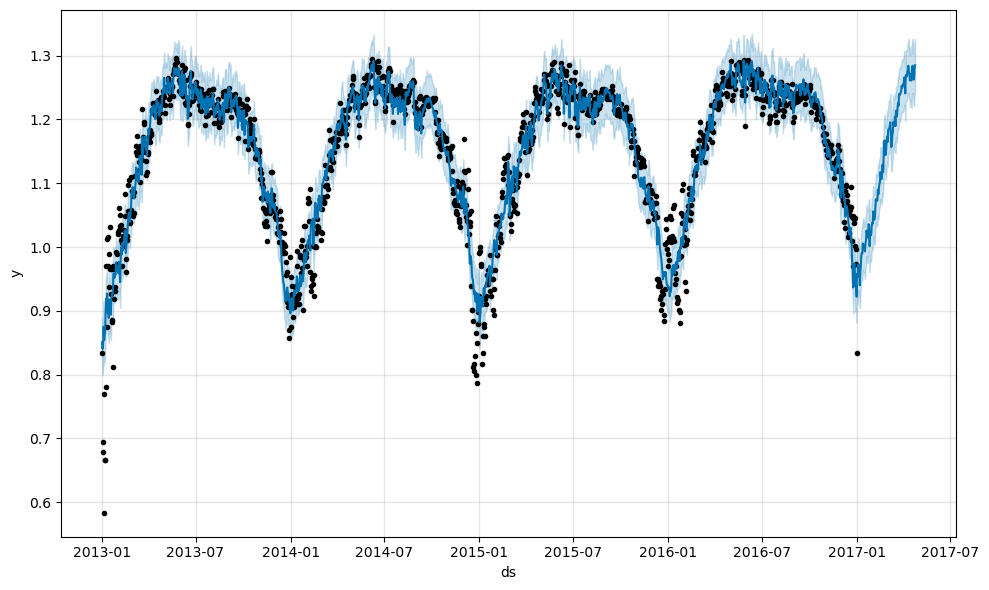

In [75]:
model_new.plot(forecast_Future_New);


In [76]:
forecast_data_orig1 = forecast_Future_New.copy()
forecast_data_orig1["yhat"] = np.exp(forecast_data_orig1["yhat"])
forecast_data_orig1["yhat_lower"] = np.exp(forecast_data_orig1["yhat_lower"])
forecast_data_orig1["yhat_upper"] = np.exp(forecast_data_orig1["yhat_upper"])

In [77]:
forecast_data_orig1.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,...,wind_speed,wind_speed_lower,wind_speed_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,1.089105,2.249799,2.433523,1.089105,1.089105,-0.238397,-0.238397,-0.238397,-0.032493,...,0.002653,0.002653,0.002653,-0.207062,-0.207062,-0.207062,0.0,0.0,0.0,2.341302
1,2013-01-02,1.089675,2.225443,2.414181,1.089675,1.089675,-0.249471,-0.249471,-0.249471,-0.044767,...,0.001491,0.001491,0.001491,-0.206041,-0.206041,-0.206041,0.0,0.0,0.0,2.316839
2,2013-01-03,1.090245,2.240881,2.424501,1.090245,1.090245,-0.242874,-0.242874,-0.242874,-0.038010,...,0.000846,0.000846,0.000846,-0.204503,-0.204503,-0.204503,0.0,0.0,0.0,2.333503
3,2013-01-04,1.090815,2.300471,2.498243,1.090815,1.090815,-0.215745,-0.215745,-0.215745,-0.013482,...,0.002172,0.002172,0.002172,-0.202500,-0.202500,-0.202500,0.0,0.0,0.0,2.399043
4,2013-01-05,1.091385,2.261076,2.445263,1.091385,1.091385,-0.237479,-0.237479,-0.237479,-0.037394,...,0.001210,0.001210,0.001210,-0.200089,-0.200089,-0.200089,0.0,0.0,0.0,2.348804


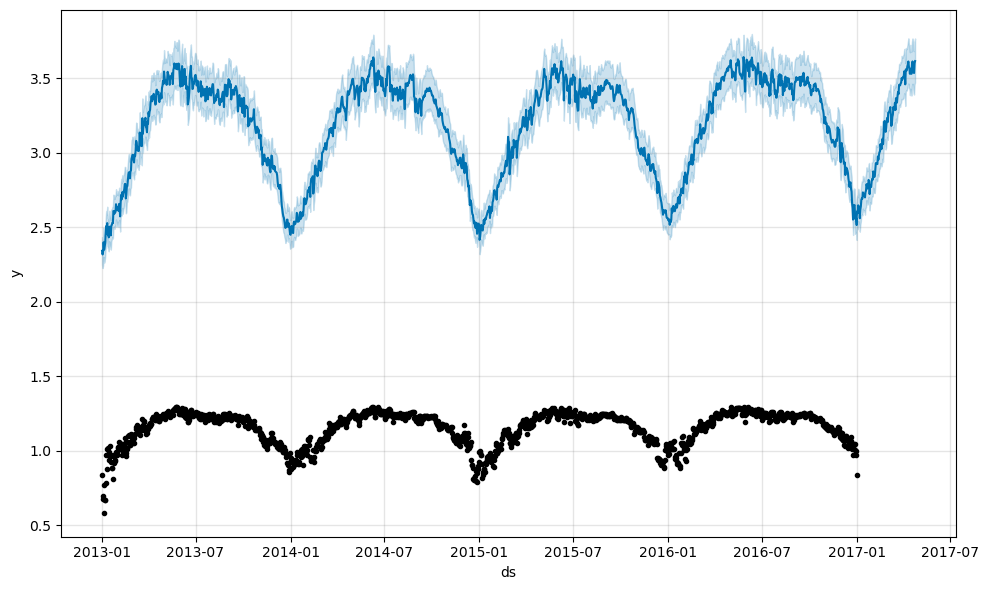

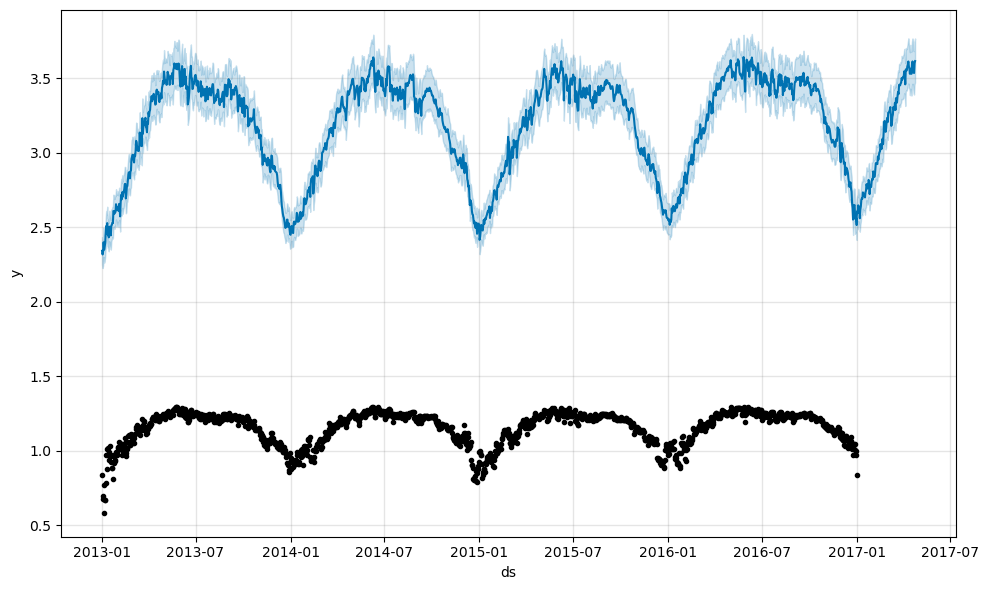

In [78]:
model_new.plot(forecast_data_orig1)